# 🍽 Food Preferences Survey — Full EDA Notebook
**Dataset:** `responses.csv` | **421 responses · 32 columns**

---


## 1. Imports & Settings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

# Inline plots, clean style
%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})
PALETTE = sns.color_palette("Set2")
print("✓ Libraries loaded")

✓ Libraries loaded


## 2. Load Raw Data

In [2]:
df_raw = pd.read_csv("C:/Users/abood/Downloads/Survey Methodology/Survey Methodology/responses.csv")
print(f"Shape: {df_raw.shape}")
df_raw.head(3)

Shape: (421, 32)


,Timestamp,Result,Name,Favourite_Cuisine,Favourite_Chef,Food Regime,Shopping_Food,Diet,Country_Famous_Foods,Preferred_Meal_Aday,...,LovingFood,Reason_BuyingFastFood,Preferred_Dessert,Preferred_Drink,LovingFood.1,OneMeal_Forever,Gender,Age,Education,Monthly_Income
0,2023-04-27 20:54:42,0,Salma Soliman,Egyptian food,Burak,"Pescetarian (no meat ,but eat fish and/ or she...",Three a month,Healthy,Koshri,Lunch,...,Well done,Delicious,Other desert,Soft drinks,Well done,Variety of fish,Female,19,Level 1,500L.E to 999L.E
1,2023-05-01 18:07:55,0,Aya Ahmed Rehan,Egyptian food,Burak Özdemir,Meatarian,Once a month,Non Healthy,Fesikh,Lunch,...,Well done,It makes them happy,Waffle,Fresh juice,Well done,Pizza,Female,20,Level 3,0 L.E
2,2023-05-01 18:19:54,0,Mariam,"Italian food, Egyptian food",Burak,None of the above,Twice a month,Non Healthy,Fish,"Breakfast, Lunch, Dinner",...,Well done,It makes them fresh and happy,"Molten cake, Other desert",Water,Well done,chicken Lasagna,Female,21,Level 3,0 L.E


In [3]:
print("Column names (raw):")
for c in df_raw.columns:
    print(f"  '{c}'")

Column names (raw):
  'Timestamp'
  'Result'
  'Name'
  'Favourite_Cuisine '
  'Favourite_Chef'
  'Food Regime'
  'Shopping_Food'
  'Diet'
  'Country_Famous_Foods'
  'Preferred_Meal_Aday'
  'Food_Allergies'
  'Preferred _Breakfast'
  'Regular_lunchFood'
  'Salt_Amount'
  'SpicyFood'
  'Preferred_Dinner'
  'EatingVarious_Vegetables/Fruits'
  'Preferred_Vegetables_or_Fruits'
  'Disliked_ingredients'
  'FastFood_Consumption'
  'Consumed_FastFood'
  'Favourite_Restaurant'
  'LovingFood'
  'Reason_BuyingFastFood '
  'Preferred_Dessert'
  'Preferred_Drink'
  'LovingFood.1'
  'OneMeal_Forever'
  'Gender'
  'Age'
  'Education'
  'Monthly_Income '


## 3. Data Cleaning

Steps applied:
1. Strip whitespace from column names and all string values
2. Normalise `FastFood_Consumption` free-text → 7 clean buckets
3. Map `Monthly_Income` → ordered categories
4. Extract `Primary_Cuisine` (first item from multi-select)
5. Fill minor nulls with `"Not specified"`


In [4]:
df = df_raw.copy()

# 3a. Strip column names and string values
df.columns = df.columns.str.strip()
df = df.apply(lambda col: col.str.strip() if col.dtype == "object" else col)

print("Stripped column names:")
for c in df.columns:
    print(f"  '{c}'")

Stripped column names:
  'Timestamp'
  'Result'
  'Name'
  'Favourite_Cuisine'
  'Favourite_Chef'
  'Food Regime'
  'Shopping_Food'
  'Diet'
  'Country_Famous_Foods'
  'Preferred_Meal_Aday'
  'Food_Allergies'
  'Preferred _Breakfast'
  'Regular_lunchFood'
  'Salt_Amount'
  'SpicyFood'
  'Preferred_Dinner'
  'EatingVarious_Vegetables/Fruits'
  'Preferred_Vegetables_or_Fruits'
  'Disliked_ingredients'
  'FastFood_Consumption'
  'Consumed_FastFood'
  'Favourite_Restaurant'
  'LovingFood'
  'Reason_BuyingFastFood'
  'Preferred_Dessert'
  'Preferred_Drink'
  'LovingFood.1'
  'OneMeal_Forever'
  'Gender'
  'Age'
  'Education'
  'Monthly_Income'


In [5]:
# 3b. Normalise FastFood_Consumption
def norm_fastfood(val):
    if pd.isna(val):
        return "Unknown"
    v = str(val).lower().strip()
    if "never" in v:                         return "Never"
    if "once a week" in v or "one time a week" in v: return "Once a week"
    if "twice" in v or "two" in v:           return "Twice a month"
    if "once a month" in v or "one time a month" in v: return "Once a month"
    if "three" in v or "3" in v:             return "3× a month"
    if any(x in v for x in ["four","4","five","5","six","6",
                              "a lot","always","more than","probably"]):
        return "4+ times a month"
    return "Other"

df["FastFood_Clean"] = df["FastFood_Consumption"].apply(norm_fastfood)
print("FastFood_Clean value counts:")
print(df["FastFood_Clean"].value_counts())

FastFood_Clean value counts:
FastFood_Clean
Twice a month       206
Once a month        134
Other                25
Never                22
4+ times a month     19
Once a week          10
3× a month            5
Name: count, dtype: int64


In [6]:
# 3c. Monthly Income → ordered categories
income_map = {
    "0 L.E":              "No Income",
    "1L.E to 499L.E":     "1–499 L.E",
    "500L.E to 999L.E":   "500–999 L.E",
    "1000L.E to 1999L.E": "1000–1999 L.E",
    "2000L.E or more":    "2000+ L.E",
}
income_order = ["No Income","1–499 L.E","500–999 L.E","1000–1999 L.E","2000+ L.E"]

df["Income_Clean"] = df["Monthly_Income"].map(income_map).fillna("Unknown")
print("Income_Clean value counts:")
print(df["Income_Clean"].value_counts().reindex(income_order))

Income_Clean value counts:
Income_Clean
No Income        198
1–499 L.E         68
500–999 L.E       55
1000–1999 L.E     47
2000+ L.E         53
Name: count, dtype: int64


In [7]:
# 3d. Primary cuisine (first item in multi-select)
df["Primary_Cuisine"] = df["Favourite_Cuisine"].str.split(",").str[0].str.strip()
print("Primary_Cuisine top 8:")
print(df["Primary_Cuisine"].value_counts().head(8))

Primary_Cuisine top 8:
Primary_Cuisine
Egyptian food    277
Italian food     133
Chinese food       7
Lebanese food      4
Name: count, dtype: int64


In [8]:
# 3e. Fill minor nulls
fill_cols = ["Food_Allergies","Preferred_Dessert","Favourite_Chef",
             "Favourite_Restaurant","Preferred_Vegetables_or_Fruits",
             "Disliked_ingredients","Consumed_FastFood","Shopping_Food"]
for col in fill_cols:
    df[col] = df[col].fillna("Not specified")

print("Null counts after cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("(No nulls shown = all clean ✓)")

Null counts after cleaning:
Series([], dtype: int64)
(No nulls shown = all clean ✓)


In [9]:
print(f"Final cleaned shape: {df.shape}")
df.head()

Final cleaned shape: (421, 35)


,Timestamp,Result,Name,Favourite_Cuisine,Favourite_Chef,Food Regime,Shopping_Food,Diet,Country_Famous_Foods,Preferred_Meal_Aday,...,Preferred_Drink,LovingFood.1,OneMeal_Forever,Gender,Age,Education,Monthly_Income,FastFood_Clean,Income_Clean,Primary_Cuisine
0,2023-04-27 20:54:42,0,Salma Soliman,Egyptian food,Burak,"Pescetarian (no meat ,but eat fish and/ or she...",Three a month,Healthy,Koshri,Lunch,...,Soft drinks,Well done,Variety of fish,Female,19,Level 1,500L.E to 999L.E,Once a week,500–999 L.E,Egyptian food
1,2023-05-01 18:07:55,0,Aya Ahmed Rehan,Egyptian food,Burak Özdemir,Meatarian,Once a month,Non Healthy,Fesikh,Lunch,...,Fresh juice,Well done,Pizza,Female,20,Level 3,0 L.E,Twice a month,No Income,Egyptian food
2,2023-05-01 18:19:54,0,Mariam,"Italian food, Egyptian food",Burak,None of the above,Twice a month,Non Healthy,Fish,"Breakfast, Lunch, Dinner",...,Water,Well done,chicken Lasagna,Female,21,Level 3,0 L.E,Twice a month,No Income,Italian food
3,2023-05-01 19:13:10,0,Tasneem Rehan,Egyptian food,Abir El Saghir,Meatarian,Three a month,Non Healthy,Kosharii,"Breakfast, Lunch, Dinner",...,Hot drinks,Well done,Chicken,Female,21,Level 3,2000L.E or more,Twice a month,2000+ L.E,Egyptian food
4,2023-05-01 21:03:29,0,Adham,"Italian food, Egyptian food",Burak,Meatarian,Twice a month,Non Healthy,kashari,Lunch,...,Cool drinks,Well done,Pasta with white sauce,Female,19,Level 2,0 L.E,Twice a month,No Income,Italian food


## 4. Dataset Overview

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421 entries, 0 to 420
Data columns (total 35 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Timestamp                        421 non-null    object
 1   Result                           421 non-null    int64 
 2   Name                             421 non-null    object
 3   Favourite_Cuisine                421 non-null    object
 4   Favourite_Chef                   421 non-null    object
 5   Food Regime                      421 non-null    object
 6   Shopping_Food                    421 non-null    object
 7   Diet                             421 non-null    object
 8   Country_Famous_Foods             421 non-null    object
 9   Preferred_Meal_Aday              421 non-null    object
 10  Food_Allergies                   421 non-null    object
 11  Preferred _Breakfast             421 non-null    object
 12  Regular_lunchFood                421

In [11]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Timestamp,421,420,2023-05-06 10:39:34,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Result,421.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Name,421,348,Mohamed,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Favourite_Cuisine,421,13,Egyptian food,263,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Favourite_Chef,421,187,Burak,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Food Regime,421,4,Meatarian,232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Shopping_Food,421,48,Three a month,180,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diet,421,2,Non Healthy,254,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country_Famous_Foods,421,228,Koshary,95,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Preferred_Meal_Aday,421,13,Lunch,217,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Demographics

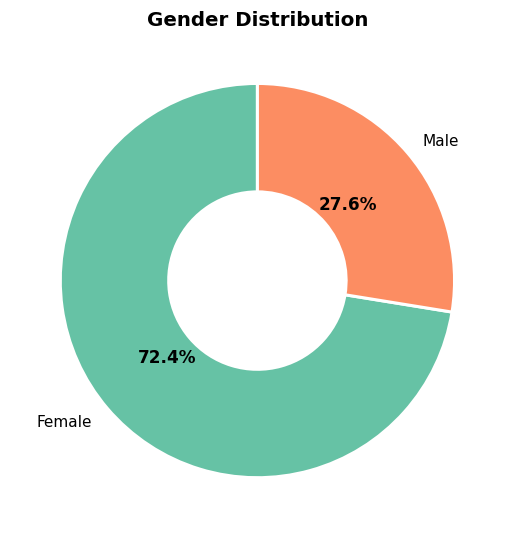

Gender
Female    305
Male      116


In [13]:
# Gender — donut chart
gender = df["Gender"].value_counts()

fig, ax = plt.subplots(figsize=(5, 5))
wedges, texts, autotexts = ax.pie(
    gender, labels=gender.index, autopct="%1.1f%%",
    colors=sns.color_palette("Set2"),
    wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2),
    startangle=90
)
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight("bold")
ax.set_title("Gender Distribution")
plt.tight_layout()
plt.show()
print(gender.to_string())

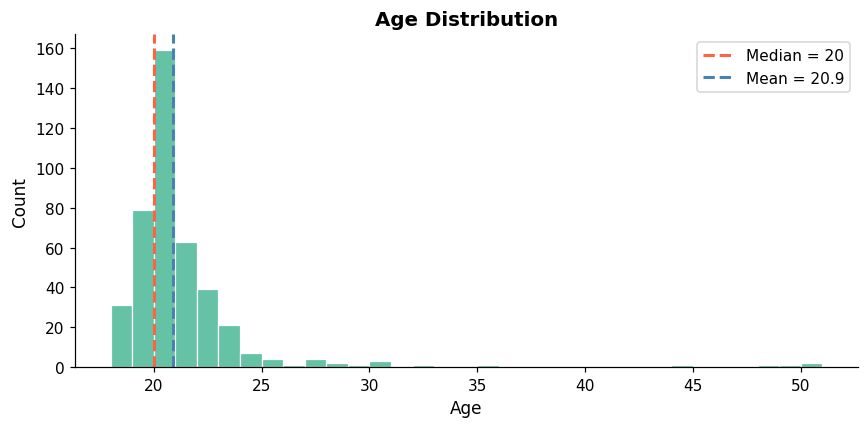

count    421.00
mean      20.87
std        3.66
min       18.00
25%       19.00
50%       20.00
75%       21.00
max       50.00
Name: Age, dtype: float64


In [14]:
# Age — histogram
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["Age"], bins=range(18, int(df["Age"].max())+2),
        color=sns.color_palette("Set2")[0], edgecolor="white", linewidth=0.8)
ax.axvline(df["Age"].median(), color="tomato", linestyle="--", linewidth=2,
           label=f"Median = {int(df['Age'].median())}")
ax.axvline(df["Age"].mean(), color="steelblue", linestyle="--", linewidth=2,
           label=f"Mean = {df['Age'].mean():.1f}")
ax.set_title("Age Distribution")
ax.set_xlabel("Age")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()
print(df["Age"].describe().round(2))

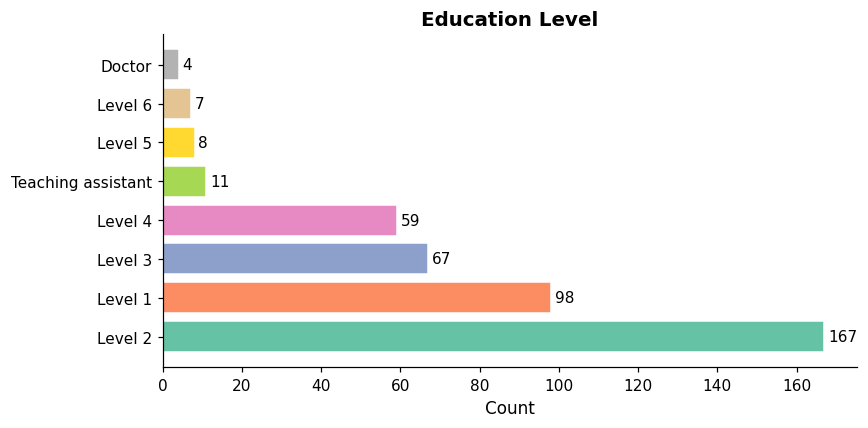

Education
Level 2               167
Level 1                98
Level 3                67
Level 4                59
Teaching assistant     11
Level 5                 8
Level 6                 7
Doctor                  4


In [15]:
# Education — horizontal bar
edu = df["Education"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(edu.index, edu.values,
               color=sns.color_palette("Set2", len(edu)), edgecolor="white")
for bar, v in zip(bars, edu.values):
    ax.text(v + 1, bar.get_y() + bar.get_height()/2, str(v),
            va="center", fontsize=10)
ax.set_title("Education Level")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()
print(edu.to_string())

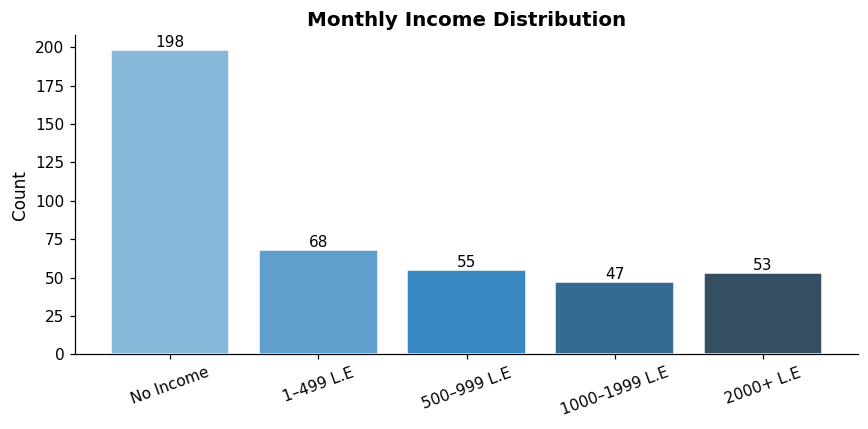

Income_Clean
No Income        198
1–499 L.E         68
500–999 L.E       55
1000–1999 L.E     47
2000+ L.E         53


In [16]:
# Monthly Income — bar chart
income_order = ["No Income","1–499 L.E","500–999 L.E","1000–1999 L.E","2000+ L.E"]
income = df["Income_Clean"].value_counts().reindex(income_order).fillna(0)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(income.index, income.values,
              color=sns.color_palette("Blues_d", len(income)), edgecolor="white")
for bar, v in zip(bars, income.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 2, str(int(v)),
            ha="center", fontsize=10)
ax.set_title("Monthly Income Distribution")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()
print(income.to_string())

## 6. Food Preferences

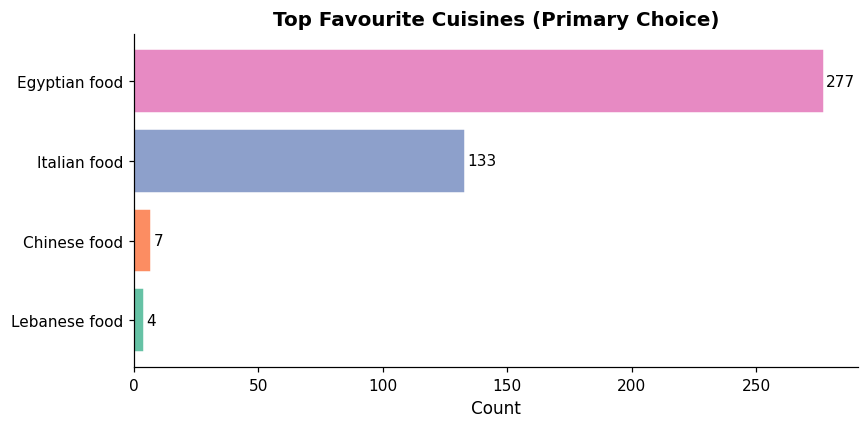

Primary_Cuisine
Egyptian food    277
Italian food     133
Chinese food       7
Lebanese food      4


In [17]:
# Favourite Cuisine (primary)
top_cuisine = df["Primary_Cuisine"].value_counts().head(8)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(top_cuisine.index[::-1], top_cuisine.values[::-1],
               color=sns.color_palette("Set2", len(top_cuisine)), edgecolor="white")
for bar, v in zip(bars, top_cuisine.values[::-1]):
    ax.text(v + 1, bar.get_y() + bar.get_height()/2, str(v),
            va="center", fontsize=10)
ax.set_title("Top Favourite Cuisines (Primary Choice)")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()
print(top_cuisine.to_string())

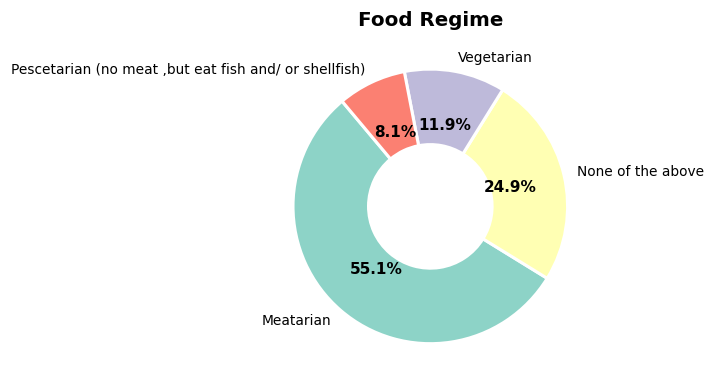

Food Regime
Meatarian                                                232
None of the above                                        105
Vegetarian                                                50
Pescetarian (no meat ,but eat fish and/ or shellfish)     34


In [49]:
# Food Regime — donut
regime = df["Food Regime"].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    regime, labels=regime.index, autopct="%1.1f%%",
    colors=sns.color_palette("Set3", len(meal)),
    wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2),
    startangle=130, textprops=dict(fontsize=9)
)
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight("bold")
ax.set_title("Food Regime")
plt.tight_layout()
plt.show()
print(regime.to_string())

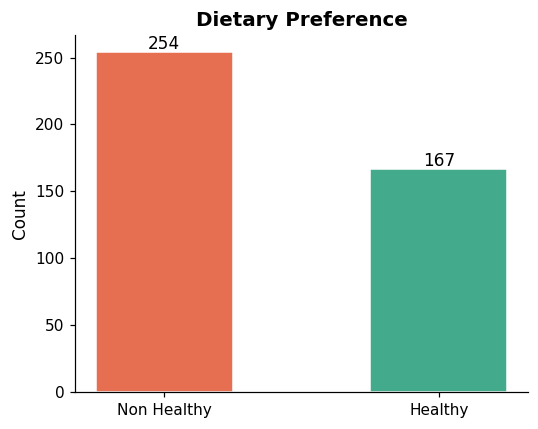

Diet
Non Healthy    254
Healthy        167


In [19]:
# Diet preference — bar
diet = df["Diet"].value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
colors = ["#43aa8b" if d == "Healthy" else "#e76f51" for d in diet.index]
bars = ax.bar(diet.index, diet.values, color=colors, edgecolor="white", width=0.5)
for bar, v in zip(bars, diet.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 2, str(v),
            ha="center", fontsize=11)
ax.set_title("Dietary Preference")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()
print(diet.to_string())

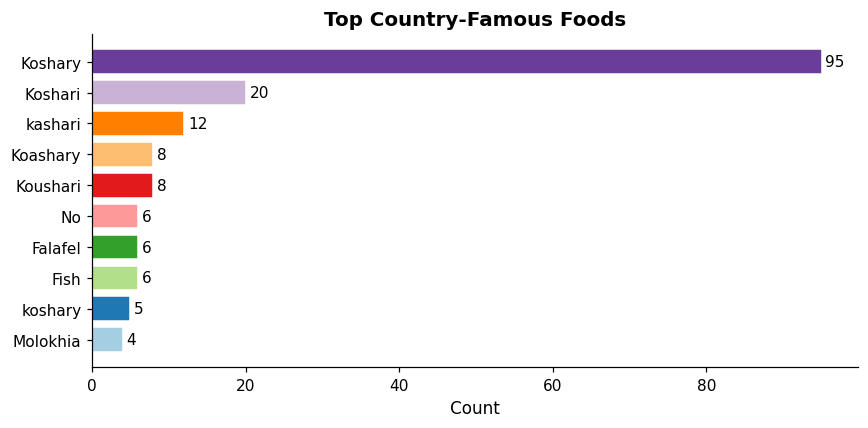

In [20]:
# Country Famous Food — top 10
top_famous = df["Country_Famous_Foods"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(top_famous.index[::-1], top_famous.values[::-1],
               color=sns.color_palette("Paired", len(top_famous)), edgecolor="white")
for bar, v in zip(bars, top_famous.values[::-1]):
    ax.text(v + 0.5, bar.get_y() + bar.get_height()/2, str(v),
            va="center", fontsize=10)
ax.set_title("Top Country-Famous Foods")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()

## 7. Meal Habits

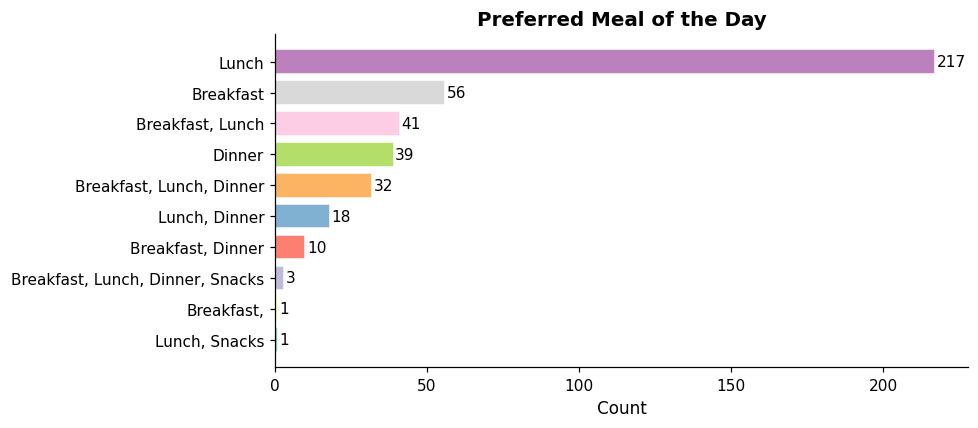

Preferred_Meal_Aday
Lunch                               217
Breakfast                            56
Breakfast, Lunch                     41
Dinner                               39
Breakfast, Lunch, Dinner             32
Lunch, Dinner                        18
Breakfast, Dinner                    10
Breakfast, Lunch, Dinner, Snacks      3
Breakfast,                            1
Lunch, Snacks                         1


In [21]:
# Preferred meal of the day
meal = df["Preferred_Meal_Aday"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(meal.index[::-1], meal.values[::-1],
               color=sns.color_palette("Set3", len(meal)), edgecolor="white")
for bar, v in zip(bars, meal.values[::-1]):
    ax.text(v + 0.5, bar.get_y() + bar.get_height()/2, str(v),
            va="center", fontsize=10)
ax.set_title("Preferred Meal of the Day")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()
print(meal.to_string())

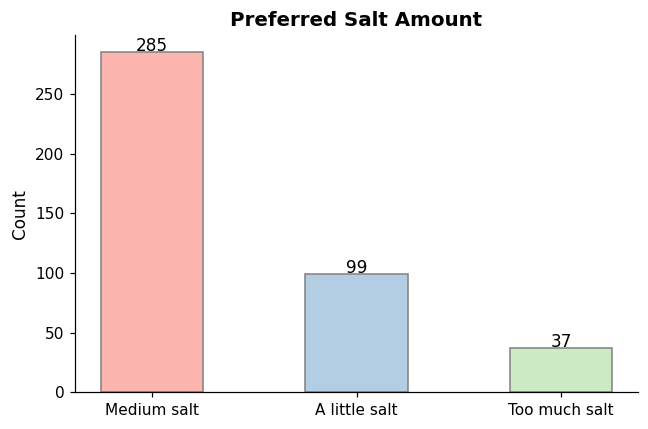

Salt_Amount
Medium salt      285
A little salt     99
Too much salt     37


In [22]:
# Salt preference
salt = df["Salt_Amount"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(salt.index, salt.values,
              color=sns.color_palette("Pastel1", len(salt)), edgecolor="grey", width=0.5)
for bar, v in zip(bars, salt.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1, str(v),
            ha="center", fontsize=11)
ax.set_title("Preferred Salt Amount")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()
print(salt.to_string())

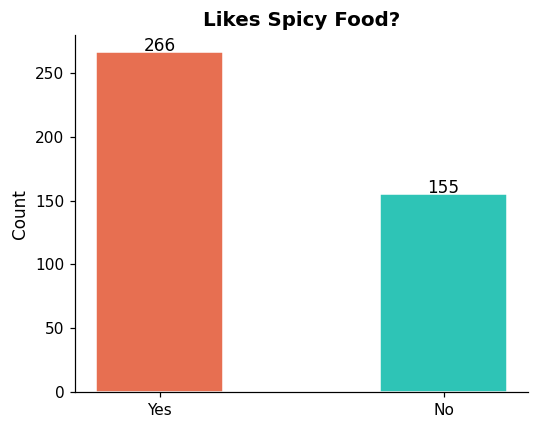

SpicyFood
Yes    266
No     155


In [23]:
# Spicy food preference
spicy = df["SpicyFood"].value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(spicy.index, spicy.values,
              color=["#e76f51","#2ec4b6"], edgecolor="white", width=0.45)
for bar, v in zip(bars, spicy.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1, str(v),
            ha="center", fontsize=11)
ax.set_title("Likes Spicy Food?")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()
print(spicy.to_string())

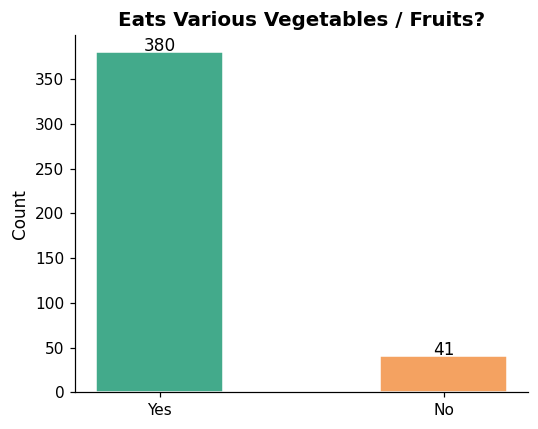

EatingVarious_Vegetables/Fruits
Yes    380
No      41


In [24]:
# Eats various vegetables / fruits
veg = df["EatingVarious_Vegetables/Fruits"].value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(veg.index, veg.values,
              color=["#43aa8b","#f4a261"], edgecolor="white", width=0.45)
for bar, v in zip(bars, veg.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1, str(v),
            ha="center", fontsize=11)
ax.set_title("Eats Various Vegetables / Fruits?")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()
print(veg.to_string())

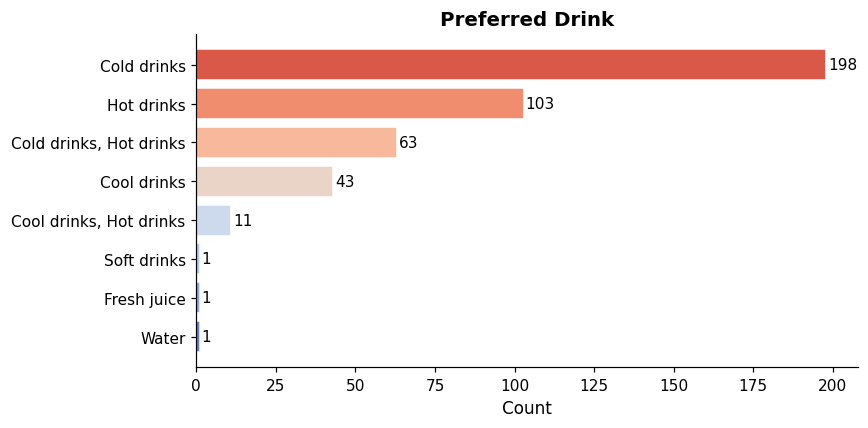

Preferred_Drink
Cold drinks                198
Hot drinks                 103
Cold drinks, Hot drinks     63
Cool drinks                 43
Cool drinks, Hot drinks     11
Soft drinks                  1
Fresh juice                  1
Water                        1


In [25]:
# Preferred drink
drink = df["Preferred_Drink"].value_counts().head(8)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(drink.index[::-1], drink.values[::-1],
               color=sns.color_palette("coolwarm", len(drink)), edgecolor="white")
for bar, v in zip(bars, drink.values[::-1]):
    ax.text(v + 0.5, bar.get_y() + bar.get_height()/2, str(v),
            va="center", fontsize=10)
ax.set_title("Preferred Drink")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()
print(drink.to_string())

## 8. Fast Food Behaviour

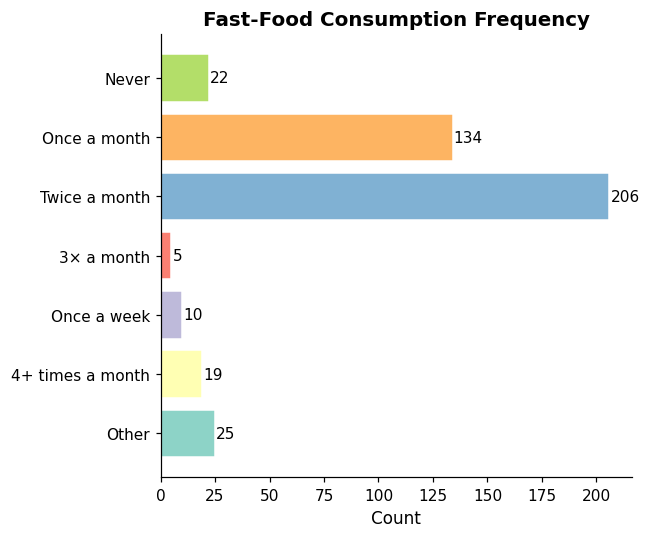

FastFood_Clean
Never                22
Once a month        134
Twice a month       206
3× a month            5
Once a week          10
4+ times a month     19
Other                25


In [53]:
# Fast-food consumption frequency (cleaned)
ff_order = ["Never","Once a month","Twice a month","3× a month",
            "Once a week","4+ times a month","Other"]
ff = df["FastFood_Clean"].value_counts().reindex(
        [x for x in ff_order if x in df["FastFood_Clean"].unique()])

fig, ax = plt.subplots(figsize=(6, 5))  # ← narrower width, more height
bars = ax.barh(ff.index[::-1], ff.values[::-1],
               color=sns.color_palette("Set3", len(meal)),
               edgecolor="white")
for bar, v in zip(bars, ff.values[::-1]):
    ax.text(v + 0.5, bar.get_y() + bar.get_height()/2, str(v),
            va="center", fontsize=10)
ax.set_title("Fast-Food Consumption Frequency")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()
print(ff.to_string())

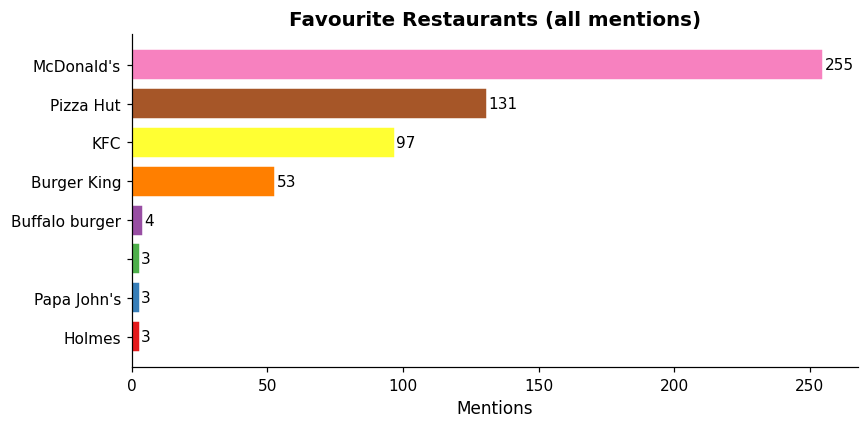

Favourite_Restaurant
McDonald's        255
Pizza Hut         131
KFC                97
Burger King        53
Buffalo burger      4
                    3
Papa John's         3
Holmes              3


In [27]:
# Favourite restaurant (exploded — each mention counts once)
rest_series = (
    df["Favourite_Restaurant"]
    .str.split(",")
    .explode()
    .str.strip()
    .replace("Not specified", np.nan)
    .dropna()
)
top_rest = rest_series.value_counts().head(8)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(top_rest.index[::-1], top_rest.values[::-1],
               color=sns.color_palette("Set1", len(top_rest)), edgecolor="white")
for bar, v in zip(bars, top_rest.values[::-1]):
    ax.text(v + 0.5, bar.get_y() + bar.get_height()/2, str(v),
            va="center", fontsize=10)
ax.set_title("Favourite Restaurants (all mentions)")
ax.set_xlabel("Mentions")
plt.tight_layout()
plt.show()
print(top_rest.to_string())

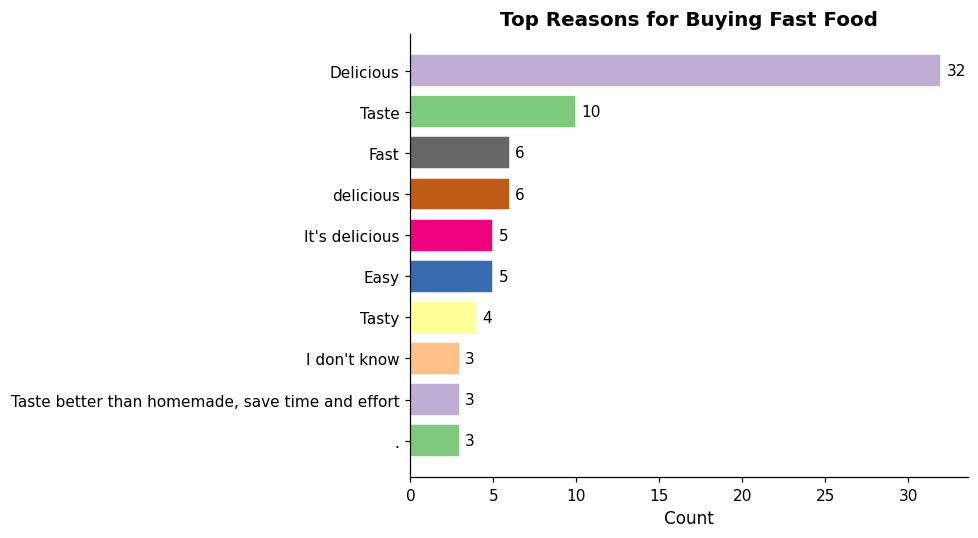

In [28]:
# Main reason for buying fast food — top 10
reason = df["Reason_BuyingFastFood"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(reason.index[::-1], reason.values[::-1],
               color=sns.color_palette("Accent", len(reason)), edgecolor="white")
for bar, v in zip(bars, reason.values[::-1]):
    ax.text(v + 0.3, bar.get_y() + bar.get_height()/2, str(v),
            va="center", fontsize=10)
ax.set_title("Top Reasons for Buying Fast Food")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()

## 9. Desserts

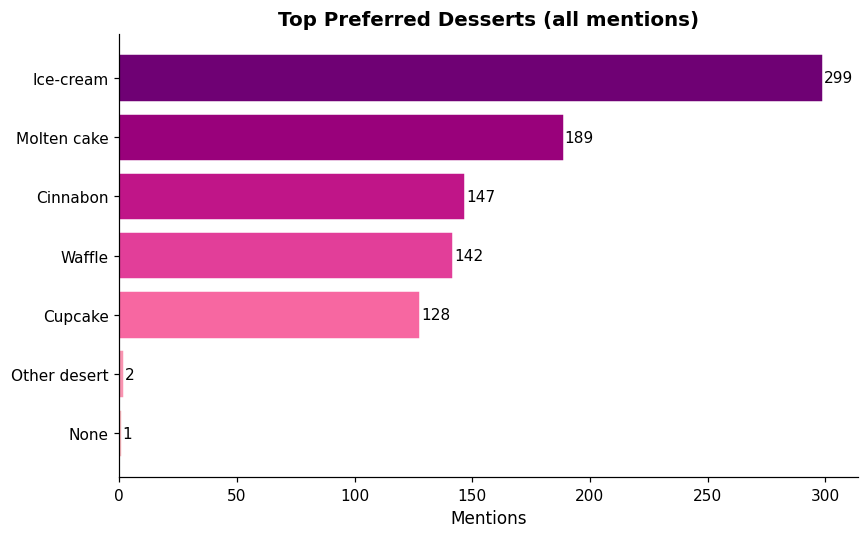

In [29]:
# Preferred dessert — top 10
dessert_series = (
    df["Preferred_Dessert"]
    .str.split(",")
    .explode()
    .str.strip()
    .replace("Not specified", np.nan)
    .dropna()
)
top_dessert = dessert_series.value_counts().head(10)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(top_dessert.index[::-1], top_dessert.values[::-1],
               color=sns.color_palette("RdPu", len(top_dessert)+2)[2:], edgecolor="white")
for bar, v in zip(bars, top_dessert.values[::-1]):
    ax.text(v + 0.3, bar.get_y() + bar.get_height()/2, str(v),
            va="center", fontsize=10)
ax.set_title("Top Preferred Desserts (all mentions)")
ax.set_xlabel("Mentions")
plt.tight_layout()
plt.show()

## 10. Cross-Variable Analysis

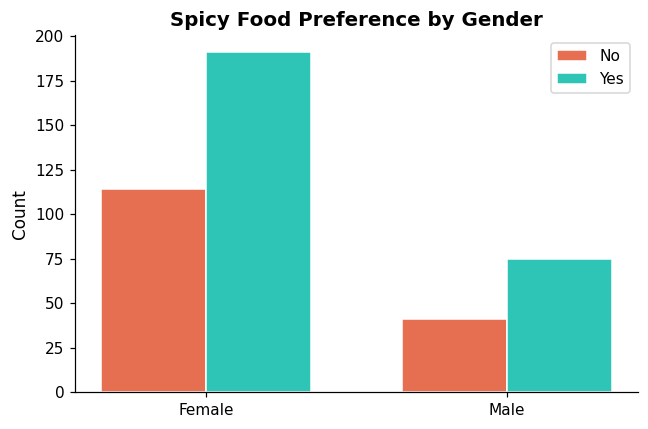

SpicyFood   No  Yes
Gender             
Female     114  191
Male        41   75


In [32]:
# Spicy preference by Gender
spicy_gender = df.groupby(["Gender","SpicyFood"]).size().unstack(fill_value=0)

x = np.arange(len(spicy_gender.index))
w = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
for i, (col, c) in enumerate(zip(spicy_gender.columns, ["#e76f51","#2ec4b6"])):
    bars = ax.bar(x + i*w, spicy_gender[col], width=w, label=col,
                  color=c, edgecolor="white")
ax.set_xticks(x + w/2)
ax.set_xticklabels(spicy_gender.index)
ax.set_title("Spicy Food Preference by Gender")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()
print(spicy_gender)

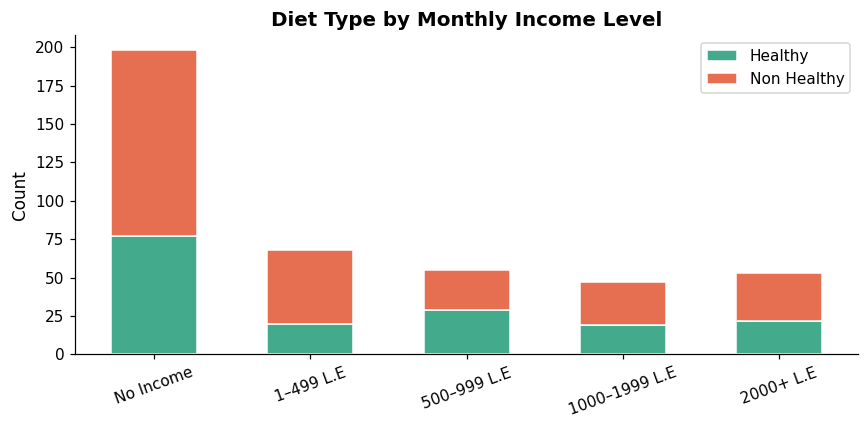

Diet           Healthy  Non Healthy
Income_Clean                       
No Income           77          121
1–499 L.E           20           48
500–999 L.E         29           26
1000–1999 L.E       19           28
2000+ L.E           22           31


In [33]:
# Diet by Income level (stacked bar)
income_order = ["No Income","1–499 L.E","500–999 L.E","1000–1999 L.E","2000+ L.E"]
diet_income = df.groupby(["Income_Clean","Diet"]).size().unstack(fill_value=0)
diet_income = diet_income.reindex([i for i in income_order if i in diet_income.index])

fig, ax = plt.subplots(figsize=(8, 4))
bottom = np.zeros(len(diet_income))
for col, c in zip(diet_income.columns, ["#43aa8b","#e76f51"]):
    vals = diet_income[col].values.astype(float)
    ax.bar(diet_income.index, vals, bottom=bottom, label=col,
           color=c, edgecolor="white", width=0.55)
    bottom += vals
ax.set_title("Diet Type by Monthly Income Level")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=20)
ax.legend()
plt.tight_layout()
plt.show()
print(diet_income)

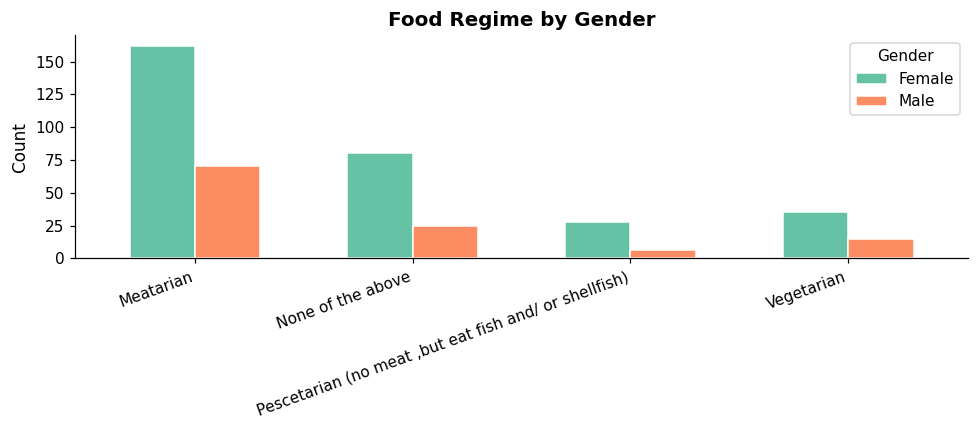

Food Regime  Meatarian  None of the above  \
Gender                                      
Female             162                 80   
Male                70                 25   

Food Regime  Pescetarian (no meat ,but eat fish and/ or shellfish)  Vegetarian  
Gender                                                                          
Female                                                      28              35  
Male                                                         6              15  


In [34]:
# Food Regime by Gender
regime_gender = df.groupby(["Gender","Food Regime"]).size().unstack(fill_value=0)

regime_gender.T.plot(kind="bar", figsize=(9, 4),
                     color=sns.color_palette("Set2", 2), edgecolor="white", width=0.6)
plt.title("Food Regime by Gender")
plt.ylabel("Count")
plt.xlabel("")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()
print(regime_gender)

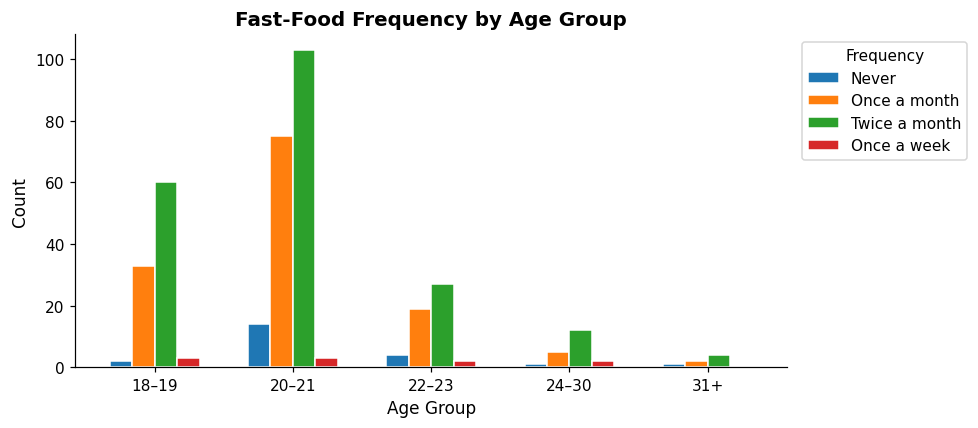

FastFood_Clean  Never  Once a month  Twice a month  Once a week
Age_Group                                                      
18–19               2            33             60            3
20–21              14            75            103            3
22–23               4            19             27            2
24–30               1             5             12            2
31+                 1             2              4            0


In [35]:
# Age group vs Fast-Food frequency
bins = [17, 19, 21, 23, 30, 60]
labels = ["18–19","20–21","22–23","24–30","31+"]
df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

age_ff = df.groupby(["Age_Group","FastFood_Clean"]).size().unstack(fill_value=0)
# Keep top 4 ff buckets for readability
keep = ["Never","Once a month","Twice a month","Once a week"]
age_ff = age_ff[[c for c in keep if c in age_ff.columns]]

age_ff.plot(kind="bar", figsize=(9, 4),
            color=sns.color_palette("tab10", len(age_ff.columns)),
            edgecolor="white", width=0.65)
plt.title("Fast-Food Frequency by Age Group")
plt.ylabel("Count")
plt.xlabel("Age Group")
plt.xticks(rotation=0)
plt.legend(title="Frequency", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()
print(age_ff)

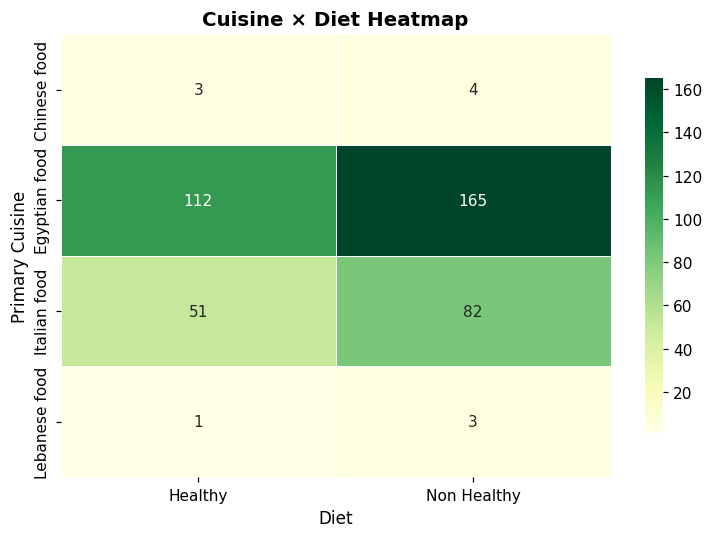

In [36]:
# Cuisine vs Diet (heatmap)
cuisine_diet = df.groupby(["Primary_Cuisine","Diet"]).size().unstack(fill_value=0)
# Keep top 8 cuisines
top8 = df["Primary_Cuisine"].value_counts().head(8).index
cuisine_diet = cuisine_diet.loc[cuisine_diet.index.isin(top8)]

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cuisine_diet, annot=True, fmt="d", cmap="YlGn",
            linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Cuisine × Diet Heatmap")
ax.set_xlabel("Diet")
ax.set_ylabel("Primary Cuisine")
plt.tight_layout()
plt.show()

## 11. Key Findings Summary

| # | Finding |
|---|---------|
| 1 | **72% Female** respondents; median age is **20** (mostly university students) |
| 2 | **~47% have no income** — consistent with a student sample |
| 3 | **Egyptian food** is the dominant favourite cuisine (62%) |
| 4 | **55% Meatarian**, 12% Vegetarian, 8% Pescetarian |
| 5 | **60% self-report a Non-Healthy diet** |
| 6 | **63% enjoy spicy food** — females slightly more than males |
| 7 | Most people eat fast food **1–2 times a month**; very few eat it weekly |
| 8 | **McDonald's** is the #1 favourite restaurant, followed by Pizza Hut & KFC |
| 9 | **Cold drinks** are preferred over hot drinks (2:1 ratio) |
| 10 | Healthy eating shows a slight upward trend with higher income |
